In [2]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


### Libraries

In [3]:
import importlib.util
import sys
import itertools

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.1",
    "sklearn": "scikit-learn>=1.3",
    "tqdm": "tqdm>=4.65",
    "termcolor": "termcolor>=2.3",
}

missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Missing packages: " + ", ".join(missing))
    print("Install them with: uv pip install " + " ".join(missing))

print("Environment ready")

Environment ready


In [4]:
from pathlib import Path
import sys
from termcolor import colored

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from models.DLinearMetadata import DLinearMetadata

print(DLinearMetadata)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

<class 'models.DLinearMetadata.DLinearMetadata'>


c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

# DLinear + numerical covariates + categorical metadata


In [5]:
FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
COMBINED_SPLIT_PATH = PROJECT_ROOT / "data/m5/processed/splits/combined_exclusive_series.csv"

### Prepare the grid of hyperparameters and scenarios

In [ ]:
PRED_LEN = 28
BATCH_SIZE = 64
RANDOM_SEED = 42

# 0 means use all available series
MAX_TRAIN_SERIES_PER_GROUP = 0
MAX_EVAL_SERIES_PER_GROUP = 0
EARLY_STOPPING_MIN_DELTA = 1e-5

GRID = {
    "seq_len": [28, 56, 112],
    "learning_rate": [1e-3, 3e-4],
    "epochs": [50],
    "samples_per_epoch": [10_000, 20_000, 40_000],
    "embedding_dim": [4],
}

TRAIN_GROUPS = ["normal", "intermittent"]
EVAL_GROUPS = ["normal", "intermittent", "cold_start_item", "cold_start_store", "all_combined"]

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [7]:
TARGET_COLUMN = "log_sales"

# Keep the stable numerical covariates from the previous notebook
COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
    "sell_price",
]

# Static categories shared by both seen and unseen items or stores
STATIC_METADATA_COLUMNS = [
    "cat_id",
    "dept_id",
    "state_id",
]

MODEL_COLUMNS = [TARGET_COLUMN] + COVARIATE_COLUMNS
N_COVARIATES = len(COVARIATE_COLUMNS)
N_CHANNELS = len(MODEL_COLUMNS)

print("Model columns:", MODEL_COLUMNS)
print("Static metadata:", STATIC_METADATA_COLUMNS)

Model columns: ['log_sales', 'day_of_week', 'is_weekend', 'event_flag', 'snap_flag', 'sell_price']
Static metadata: ['cat_id', 'dept_id', 'state_id']


### Read data and prepare series

In [8]:
def sample_ids(series_ids, max_count, seed):
    series_ids = list(series_ids)

    # If max_count is 0, None, or larger than the data, use all series
    if max_count is None or max_count <= 0 or max_count >= len(series_ids):
        return series_ids

    return (
        pd.Series(series_ids)
        .sample(n=max_count, random_state=seed)
        .astype(int)
        .tolist()
    )

#### Read data and set subsets

In [9]:
df_combined = pd.read_csv(COMBINED_SPLIT_PATH)

split_ids = {}

# Series ids for each subset
for split_name in ["normal", "intermittent", "cold_start_item", "cold_start_store"]:
    ids = (
        df_combined[df_combined["exclusive_split"] == split_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    split_ids[split_name] = sample_ids(
        ids,
        MAX_EVAL_SERIES_PER_GROUP,
        RANDOM_SEED,
    )

# Concatenate all individual exclusive subsets
split_ids["all_combined"] = (
    split_ids["normal"]
    + split_ids["intermittent"]
    + split_ids["cold_start_item"]
    + split_ids["cold_start_store"]
)

train_ids = []

# Series ids for training (only consider normal and intermittent series)
# cold-start is not used for training
for group_name in TRAIN_GROUPS:
    ids = (
        df_combined[df_combined["exclusive_split"] == group_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )

    train_ids.extend(
        sample_ids(
            ids,
            MAX_TRAIN_SERIES_PER_GROUP,
            RANDOM_SEED,
        )
    )

print("Train groups:", TRAIN_GROUPS)
print("Train series:", len(train_ids))

for split_name, ids in split_ids.items():
    print(split_name, len(ids))

Train groups: ['normal', 'intermittent']
Train series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


#### Scale covariates

The scaler is fitted only on training-series observations before the validation horizon.


In [11]:
def fit_covariate_scaler(series_ids, pred_len):
    scaler_df = pd.read_parquet(
        FEATURE_PATH,
        columns=["series_idx", "time_idx"] + COVARIATE_COLUMNS,
        filters=[("series_idx", "in", list(series_ids))],
    )

    scaler_df = scaler_df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Exclude the final validation horizon from scaler fitting.
    position_from_end = scaler_df.groupby("series_idx").cumcount(ascending=False)
    scaler_df = scaler_df[position_from_end >= pred_len]

    # Dealing with null and inf values
    covariates = (
        scaler_df[COVARIATE_COLUMNS]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )
    
    # scaler =  StandardScaler()
    scaler = RobustScaler()
    scaler.fit(covariates)

    return scaler

#Scaler is trained only using the training series
covariate_scaler = fit_covariate_scaler(train_ids, PRED_LEN)
covariate_scaler


,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


#### Encode categorical metadata


In [12]:
def fit_metadata_encoders(series_table, series_ids):
    # The split table already has one row and static metadata per series
    metadata_df = series_table[
        series_table["series_idx"].isin(series_ids)
    ][["series_idx"] + STATIC_METADATA_COLUMNS].copy()

    encoders = {}
    cardinalities = []

    for column in STATIC_METADATA_COLUMNS:
        known_values = sorted(
            metadata_df[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        # Known categories start at index 1 
        # index 0 is the unknown category
        encoders[column] = {
            value: encoded_value
            for encoded_value, value in enumerate(known_values, start=1)
        }
        cardinalities.append(len(known_values) + 1)

    return encoders, cardinalities


metadata_encoders, metadata_cardinalities = fit_metadata_encoders(
    df_combined,
    train_ids,
)

metadata_summary = pd.DataFrame({
    "metadata_column": STATIC_METADATA_COLUMNS,
    "known_training_categories": [
        len(metadata_encoders[column])
        for column in STATIC_METADATA_COLUMNS
    ],
    "embedding_cardinality": metadata_cardinalities,
})

metadata_summary

,metadata_column,known_training_categories,embedding_cardinality
0,cat_id,3,4
1,dept_id,7,8
2,state_id,3,4


#### Load arrays

In [13]:
def load_series_arrays(
    series_ids,
    seq_len,
    pred_len,
    covariate_scaler,
    metadata_encoders,
):
    # Read parquet filtering columns
    df = pd.read_parquet(
        FEATURE_PATH,
        columns=(
            ["series_idx", "time_idx", "sales"] + MODEL_COLUMNS + STATIC_METADATA_COLUMNS),
        filters=[("series_idx", "in", list(series_ids))],
    )
    df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    # Lists to store one array per time series
    model_arrays = []
    sales_arrays = []
    metadata_arrays = []
    clean_ids = []

    #Enough length validation
    minimum_length = seq_len + pred_len + pred_len

    # Create one log_sales array and one sales array for each series
    for series_idx, group in df.groupby("series_idx", sort=True):
        group = group.sort_values("time_idx")

        log_series = group[[TARGET_COLUMN]].to_numpy(dtype=np.float32).copy()
        sales_series = group["sales"].to_numpy(dtype=np.float32).copy()

        # Dealing with null and inf values
        covariate_values = (
            group[COVARIATE_COLUMNS]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
            .to_numpy(dtype=np.float32)
            .copy()
        )
        
        # Scaling
        covariate_values = covariate_scaler.transform(covariate_values).astype(np.float32)

        # Channel 0 is log_sales. the other channels are scaled covariates
        model_values = np.concatenate([log_series, covariate_values], axis=1)

        # Use the first row because these metadata columns are static per series
        metadata_row = group.iloc[0]
        encoded_metadata = []

        for column in STATIC_METADATA_COLUMNS:
            raw_value = metadata_row[column]

            if pd.isna(raw_value):
                encoded_value = 0
            else:
                encoded_value = metadata_encoders[column].get(str(raw_value), 0)

            encoded_metadata.append(encoded_value)

        encoded_metadata = np.asarray(encoded_metadata, dtype=np.int64)

        if len(model_values) >= minimum_length and not np.isnan(model_values).any():
            model_arrays.append(model_values)
            sales_arrays.append(sales_series)
            metadata_arrays.append(encoded_metadata)
            clean_ids.append(int(series_idx))

    return model_arrays, sales_arrays, metadata_arrays, clean_ids

### Windowing class for batch extraction

In [15]:
class RandomWindowDataset(Dataset):
    def __init__(
        self,
        series_arrays,
        metadata_arrays,
        seq_len,
        pred_len,
        samples_per_epoch,
        seed=42,
    ):
        self.series_arrays = series_arrays
        self.metadata_arrays = metadata_arrays
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.samples_per_epoch = samples_per_epoch
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        # Choose one time series
        series_position = self.rng.integers(0, len(self.series_arrays))
        series = self.series_arrays[series_position]
        metadata = self.metadata_arrays[series_position]

        # Reserve the validation part of the window 
        validation_start = len(series) - self.pred_len
        max_start = validation_start - self.seq_len - self.pred_len

        # Choose window
        start = self.rng.integers(0, max_start + 1)

        # Input window and target window
        x = series[start : start + self.seq_len].copy()
        y = series[
            start + self.seq_len : start + self.seq_len + self.pred_len,
            0:1,
        ].copy()

        return (
            torch.from_numpy(x),
            torch.from_numpy(y),
            torch.from_numpy(metadata.copy()),
        )

### Validation series function and evaluation metrics

In [16]:
def build_validation_tensors(
    series_arrays,
    sales_arrays,
    metadata_arrays,
    seq_len,
    pred_len,
):
    x_values = []
    y_log_values = []
    y_sales_values = []
    metadata_values = []

    # One validation example for each series
    for model_series, sales_series, metadata in zip(
        series_arrays,
        sales_arrays,
        metadata_arrays,
    ):
        #validation start number
        validation_start = len(model_series) - pred_len

        x = model_series[validation_start - seq_len : validation_start]
        y_log = model_series[validation_start : validation_start + pred_len, 0:1]
        y_sales = sales_series[validation_start : validation_start + pred_len]

        x_values.append(x)
        y_log_values.append(y_log)
        y_sales_values.append(y_sales)
        metadata_values.append(metadata)

    # Turn lists into arrays
    return (
        np.stack(x_values).astype(np.float32),
        np.stack(y_log_values).astype(np.float32),
        np.stack(y_sales_values).astype(np.float32),
        np.stack(metadata_values).astype(np.int64),
    )

In [17]:
def calculate_metrics(pred_sales, actual_sales, zero_threshold=0.5):
    mae = np.mean(np.abs(pred_sales - actual_sales))                # sum(abs(y_hat - y)) / n
    rmse = np.sqrt(np.mean((pred_sales - actual_sales) ** 2))       # sqrt(  sum((y_hat - y)^2) / n  )
    wape = np.sum(np.abs(pred_sales - actual_sales)) / (
        np.sum(np.abs(actual_sales)) + 1e-8                         #  sum(abs(y_hat - y))   /   sum(abs(y))
    )

    actual_zero = actual_sales == 0
    predicted_zero = pred_sales < zero_threshold

    true_positive = np.sum(predicted_zero & actual_zero)
    false_positive = np.sum(predicted_zero & ~actual_zero)
    false_negative = np.sum(~predicted_zero & actual_zero)

    zero_precision = true_positive / (true_positive + false_positive + 1e-8)    # tp / (tp + fp)
    zero_recall = true_positive / (true_positive + false_negative + 1e-8)       # tp / (tp + fn)
    zero_f1 = (
        2 * zero_precision * zero_recall
        / (zero_precision + zero_recall + 1e-8)                                 # 2*P*R / (P + R)
    )

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "wape": float(wape),
        "zero_precision": float(zero_precision),
        "zero_recall": float(zero_recall),
        "zero_f1": float(zero_f1),
    }

### Evaluation function

In [18]:
def evaluate_model_on_subset(
    model,
    series_arrays,
    sales_arrays,
    metadata_arrays,
    seq_len,
    pred_len,
):
    # Validation data
    x_val, y_val_log, actual_sales, metadata_val = build_validation_tensors(
        series_arrays,
        sales_arrays,
        metadata_arrays,
        seq_len,
        pred_len,
    )

    # Evaluation mode
    model.eval()

    # Predict
    with torch.no_grad():
        x_tensor = torch.from_numpy(x_val.copy()).to(device)
        metadata_tensor = torch.from_numpy(metadata_val.copy()).long().to(device)
        pred_log = model(x_tensor, metadata_tensor).cpu().numpy().squeeze(-1)

    pred_sales = np.expm1(pred_log)
    pred_sales = np.clip(pred_sales, 0, None)

    # Baseline 1: repeat the last observed value.
    last_value_forecast = np.repeat(x_val[:, -1:, 0], pred_len, axis=1)
    last_value_forecast = np.expm1(last_value_forecast)

    # Baseline 2: repeat the previous forecast-length period.
    seasonal_naive_forecast = []

    for sales_series in sales_arrays:
        validation_start = len(sales_series) - pred_len
        previous_n_days = sales_series[validation_start - pred_len : validation_start]
        seasonal_naive_forecast.append(previous_n_days)

    seasonal_naive_forecast = np.stack(seasonal_naive_forecast)

    # Baseline 3: predict zero demand for every day.
    zero_forecast = np.zeros_like(actual_sales)

    return {
        "zero": calculate_metrics(zero_forecast, actual_sales),
        "last_value": calculate_metrics(last_value_forecast, actual_sales),
        "seasonal_naive_28": calculate_metrics(seasonal_naive_forecast, actual_sales),
        "global_dlinear_metadata": calculate_metrics(pred_sales, actual_sales),
    }

### Training and setting model parameters

In [20]:
def train_global_dlinear_metadata(
    train_model_arrays,
    train_metadata_arrays,
    seq_len,
    pred_len,
    learning_rate,
    epochs,
    samples_per_epoch,
    embedding_dim,
    min_delta=1e-4,
):
    # Call window generator for training batches
    train_dataset = RandomWindowDataset(
        series_arrays=train_model_arrays,
        metadata_arrays=train_metadata_arrays,
        seq_len=seq_len,
        pred_len=pred_len,
        samples_per_epoch=samples_per_epoch,
        seed=RANDOM_SEED,
    )

    #Group into batches
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    # Set seed
    torch.manual_seed(RANDOM_SEED)

    model = DLinearMetadata(
        seq_len=seq_len,
        pred_len=pred_len,
        n_covariates=N_COVARIATES,
        metadata_cardinalities=metadata_cardinalities,
        embedding_dim=embedding_dim,
    ).to(device)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.MSELoss()

    best_train_loss = float("inf")
    best_state = None
    best_epoch = None
    previous_train_loss = None
    training_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for x, y, metadata in tqdm(
            train_loader,
            desc=f"seq={seq_len}, lr={learning_rate}, epoch={epoch}",
        ):
            x = x.to(device)
            y = y.to(device)
            metadata = metadata.long().to(device)

            optimizer.zero_grad()
            prediction = model(x, metadata) # Forward pass
            loss = loss_fn(prediction, y) # Training loss
            loss.backward()# Gradients backpropagation
            optimizer.step() # Update weights
            
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        training_history.append({
            "epoch": epoch,
            "train_mse_log": train_loss,
        })

        # Save model weights if has the best training loss
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        # Simple early stopping
        if previous_train_loss is not None:
            loss_difference = abs(previous_train_loss - train_loss)

            if loss_difference < min_delta:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Loss difference: {loss_difference:.6f}"
                )
                break

        previous_train_loss = train_loss

     # Set model weights using the epoch with lowest loss
    model.load_state_dict(best_state)

    return model, best_epoch, best_train_loss, len(training_history), training_history

### Grid search

In [ ]:
#[grid_combinations[0]]

In [26]:
# %%capture

all_results = []

# List of all hyperparameters combinations
grid_combinations = list(itertools.product(
    GRID["seq_len"],
    GRID["learning_rate"],
    GRID["epochs"],
    GRID["samples_per_epoch"],
    GRID["embedding_dim"],
))

# Train and evaluate every grid search combination
for seq_len, learning_rate, epochs, samples_per_epoch, embedding_dim in grid_combinations: #[grid_combinations[0]]: #grid_combinations:
    print(colored("\n----Grid run----", "green", attrs=["bold"]))
    print("seq_len:", colored(seq_len, attrs=["bold"]))
    print("learning_rate:", colored(learning_rate, attrs=["bold"]))
    print("epochs:", colored(epochs, attrs=["bold"]))
    print("samples_per_epoch:", colored(samples_per_epoch, attrs=["bold"]))
    print("embedding_dim:", colored(embedding_dim, attrs=["bold"]))

    train_model_arrays, train_sales_arrays, train_metadata_arrays, clean_train_ids = (
        load_series_arrays(
            train_ids,
            seq_len,
            PRED_LEN,
            covariate_scaler,
            metadata_encoders,
        )
    )

    print("\nLoaded train series:", len(train_model_arrays))

    model, best_epoch, best_train_loss, epochs_ran, training_history = (
        train_global_dlinear_metadata(
            train_model_arrays=train_model_arrays,
            train_metadata_arrays=train_metadata_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN,
            learning_rate=learning_rate,
            epochs=epochs,
            samples_per_epoch=samples_per_epoch,
            embedding_dim=embedding_dim,
            min_delta=EARLY_STOPPING_MIN_DELTA,
        )
    )

    # evaluate each subset
    for subset_name in EVAL_GROUPS:
        eval_model_arrays, eval_sales_arrays, eval_metadata_arrays, clean_eval_ids = (
            load_series_arrays(
                split_ids[subset_name],
                seq_len,
                PRED_LEN,
                covariate_scaler,
                metadata_encoders,
            )
        )

        subset_metrics = evaluate_model_on_subset(
            model=model,
            series_arrays=eval_model_arrays,
            sales_arrays=eval_sales_arrays,
            metadata_arrays=eval_metadata_arrays,
            seq_len=seq_len,
            pred_len=PRED_LEN,
        )

        # One record per subset -- model (including baselines) -- grid of hyperparameters
        for model_name, metrics in subset_metrics.items():
            all_results.append({
                "train_groups": "+".join(TRAIN_GROUPS),
                "subset": subset_name,
                "model": model_name,
                "seq_len": seq_len,
                "pred_len": PRED_LEN,
                "learning_rate": learning_rate,
                "early_stop_delta": EARLY_STOPPING_MIN_DELTA,
                "epochs": epochs,
                "epochs_ran": epochs_ran,
                "samples_per_epoch": samples_per_epoch,
                "batch_size": BATCH_SIZE,
                "embedding_dim": embedding_dim,
                "metadata_columns": "+".join(STATIC_METADATA_COLUMNS),
                "best_epoch": best_epoch,
                "best_train_mse_log": best_train_loss,
                "n_train_series": len(train_model_arrays),
                "n_eval_series": len(eval_model_arrays),
                "mae": metrics["mae"],
                "rmse": metrics["rmse"],
                "wape": metrics["wape"],
                "zero_precision": metrics["zero_precision"],
                "zero_recall": metrics["zero_recall"],
                "zero_f1": metrics["zero_f1"],
            })

    print(colored("----------------------------", "green", attrs=["bold"]))

results_df = pd.DataFrame(all_results)
results_df


----Grid run----
seq_len: 28
learning_rate: 0.001
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.001, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 280.46it/s]


----------------------------

----Grid run----
seq_len: 28
learning_rate: 0.001
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.001, epoch=50: 100%|██████████| 313/313 [00:01<00:00, 281.85it/s]


----------------------------

----Grid run----
seq_len: 28
learning_rate: 0.001
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.001, epoch=50: 100%|██████████| 625/625 [00:02<00:00, 309.93it/s]


----------------------------

----Grid run----
seq_len: 28
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.0003, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 506.05it/s]


----------------------------

----Grid run----
seq_len: 28
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.0003, epoch=50: 100%|██████████| 313/313 [00:00<00:00, 397.39it/s]


Early stopping at epoch 50. Loss difference: 0.000005
----------------------------

----Grid run----
seq_len: 28
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=28, lr=0.0003, epoch=50: 100%|██████████| 625/625 [00:02<00:00, 298.94it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.001
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.001, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 437.37it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.001
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.001, epoch=50: 100%|██████████| 313/313 [00:00<00:00, 403.85it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.001
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.001, epoch=50: 100%|██████████| 625/625 [00:01<00:00, 387.36it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.0003, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 463.08it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.0003, epoch=50: 100%|██████████| 313/313 [00:00<00:00, 400.57it/s]


----------------------------

----Grid run----
seq_len: 56
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=56, lr=0.0003, epoch=50: 100%|██████████| 625/625 [00:01<00:00, 421.02it/s]


----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.001
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.001, epoch=27: 100%|██████████| 157/157 [00:00<00:00, 470.45it/s]


Early stopping at epoch 27. Loss difference: 0.000000
----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.001
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.001, epoch=50: 100%|██████████| 313/313 [00:00<00:00, 368.29it/s]


----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.001
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.001, epoch=50: 100%|██████████| 625/625 [00:01<00:00, 333.97it/s]


----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 10000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.0003, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 438.70it/s]


----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 20000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.0003, epoch=50: 100%|██████████| 313/313 [00:00<00:00, 371.38it/s]


----------------------------

----Grid run----
seq_len: 112
learning_rate: 0.0003
epochs: 50
samples_per_epoch: 40000
embedding_dim: 4

Loaded train series: 24696


seq=112, lr=0.0003, epoch=50: 100%|██████████| 625/625 [00:01<00:00, 370.05it/s]


----------------------------


,train_groups,subset,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_epoch,best_train_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,normal+intermittent,normal,zero,28,28,0.0010,0.00001,50,50,10000,...,36,0.198152,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
1,normal+intermittent,normal,last_value,28,28,0.0010,0.00001,50,50,10000,...,36,0.198152,24696,7600,2.569666,4.997246,0.860287,0.481517,0.459236,0.470113
2,normal+intermittent,normal,seasonal_naive_28,28,28,0.0010,0.00001,50,50,10000,...,36,0.198152,24696,7600,2.351133,4.454990,0.787125,0.466804,0.479820,0.473222
3,normal+intermittent,normal,global_dlinear_metadata,28,28,0.0010,0.00001,50,50,10000,...,36,0.198152,24696,7600,1.877867,3.819710,0.628682,0.610172,0.381053,0.469132
4,normal+intermittent,intermittent,zero,28,28,0.0010,0.00001,50,50,10000,...,36,0.198152,24696,17096,0.627133,1.633125,1.000000,0.679888,1.000000,0.809444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,normal+intermittent,cold_start_store,global_dlinear_metadata,112,28,0.0003,0.00001,50,50,40000,...,24,0.204231,24696,2744,1.060049,2.270829,0.718330,0.770332,0.673138,0.718463
356,normal+intermittent,all_combined,zero,112,28,0.0003,0.00001,50,50,40000,...,24,0.204231,24696,30490,1.386433,3.851429,1.000000,0.562784,1.000000,0.720233
357,normal+intermittent,all_combined,last_value,112,28,0.0003,0.00001,50,50,40000,...,24,0.204231,24696,30490,1.350344,3.300666,0.973970,0.701506,0.699573,0.700539
358,normal+intermittent,all_combined,seasonal_naive_28,112,28,0.0003,0.00001,50,50,40000,...,24,0.204231,24696,30490,1.258023,2.836503,0.907380,0.696423,0.710400,0.703342


In [ ]:
# output_path = PROJECT_ROOT / "notebooks/Results/dlinear_metadata_v1_grid_results.csv"

# output_path.parent.mkdir(parents=True, exist_ok=True)
# results_df.to_csv(output_path, index=False)

# output_path

WindowsPath('c:/Users/Francisco/Documents/Documentos-secundario/Visual-Studio-Code-Repository/CT5108_Capstone/Unified_forecasting/notebooks/Results/dlinear_metadata_v1_grid_results.csv')

In [28]:
results_df.sort_values(
    ["subset", "wape"],
    ascending=[True, True],
).reset_index(drop=True)

,train_groups,subset,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_epoch,best_train_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,normal+intermittent,all_combined,global_dlinear_metadata,56,28,0.0003,0.00001,50,50,10000,...,36,0.196942,24696,30490,0.999565,2.321597,0.720962,0.761218,0.755397,0.758296
1,normal+intermittent,all_combined,global_dlinear_metadata,28,28,0.0003,0.00001,50,50,10000,...,36,0.196028,24696,30490,1.001234,2.342761,0.722165,0.760219,0.759156,0.759687
2,normal+intermittent,all_combined,global_dlinear_metadata,28,28,0.0003,0.00001,50,50,40000,...,43,0.200460,24696,30490,1.006424,2.318190,0.725909,0.770689,0.731951,0.750820
3,normal+intermittent,all_combined,global_dlinear_metadata,56,28,0.0003,0.00001,50,50,20000,...,16,0.200499,24696,30490,1.007524,2.345674,0.726702,0.761959,0.752023,0.756958
4,normal+intermittent,all_combined,global_dlinear_metadata,112,28,0.0003,0.00001,50,50,20000,...,41,0.200276,24696,30490,1.007527,2.357813,0.726704,0.765299,0.745881,0.755465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,normal+intermittent,normal,zero,112,28,0.0010,0.00001,50,50,20000,...,41,0.208770,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
356,normal+intermittent,normal,zero,112,28,0.0010,0.00001,50,50,40000,...,24,0.212378,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
357,normal+intermittent,normal,zero,112,28,0.0003,0.00001,50,50,10000,...,36,0.202539,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892
358,normal+intermittent,normal,zero,112,28,0.0003,0.00001,50,50,20000,...,41,0.200276,24696,7600,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892


In [29]:
best_metadata_by_subset = (
    results_df[results_df["model"] == "global_dlinear_metadata"]
    .sort_values(["subset", "wape"])
    .groupby("subset", as_index=False)
    .first()
)

best_metadata_by_subset

,subset,train_groups,model,seq_len,pred_len,learning_rate,early_stop_delta,epochs,epochs_ran,samples_per_epoch,...,best_epoch,best_train_mse_log,n_train_series,n_eval_series,mae,rmse,wape,zero_precision,zero_recall,zero_f1
0,all_combined,normal+intermittent,global_dlinear_metadata,56,28,0.0003,0.00001,50,50,10000,...,36,0.196942,24696,30490,0.999565,2.321597,0.720962,0.761218,0.755397,0.758296
1,cold_start_item,normal+intermittent,global_dlinear_metadata,56,28,0.0003,0.00001,50,50,10000,...,36,0.196942,24696,3050,1.120309,2.687526,0.711799,0.751255,0.727695,0.739287
2,cold_start_store,normal+intermittent,global_dlinear_metadata,56,28,0.0003,0.00001,50,50,10000,...,36,0.196942,24696,2744,1.054810,2.315550,0.714780,0.759408,0.711408,0.734625
3,intermittent,normal+intermittent,global_dlinear_metadata,56,28,0.0010,0.00001,50,50,10000,...,36,0.201031,24696,17096,0.588989,1.233183,0.939177,0.763573,0.882444,0.818716
4,normal,normal+intermittent,global_dlinear_metadata,28,28,0.0003,0.00001,50,50,40000,...,43,0.200460,24696,7600,1.826291,3.672891,0.611416,0.645941,0.307959,0.417073


## Explore results

In [30]:
scatter_df = results_df.copy()

subsets_order = [
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
    "all_combined",
]

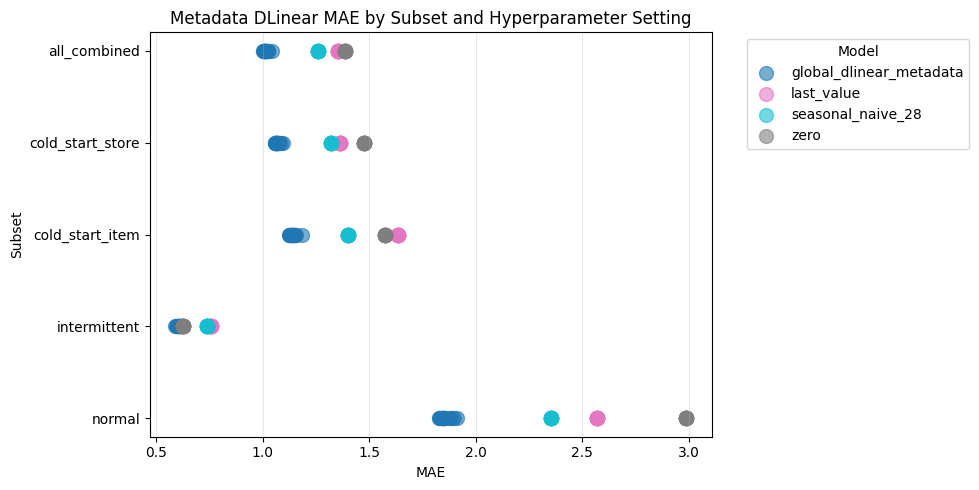

In [31]:
model_colors = {
    "zero": "tab:gray",
    "last_value": "tab:pink",
    "seasonal_naive_28": "tab:cyan",
    "global_dlinear_metadata": "tab:blue",
}

# Convert categorical subset labels to numeric y positions.
subset_to_y = {subset: i for i, subset in enumerate(subsets_order)}
scatter_df["subset_y"] = scatter_df["subset"].map(subset_to_y)

plt.figure(figsize=(10, 5))

for model_name, model_data in scatter_df.groupby("model"):
    plt.scatter(
        model_data["mae"],
        model_data["subset_y"],
        label=model_name,
        color=model_colors.get(model_name),
        alpha=0.6,
        s=100,
    )

plt.yticks(
    ticks=range(len(subsets_order)),
    labels=subsets_order,
)

plt.xlabel("MAE")
plt.ylabel("Subset")
plt.title("Metadata DLinear MAE by Subset and Hyperparameter Setting")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Compare with DLinear


In [33]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "dlinear_mae",
            "rmse": "dlinear_rmse",
            "wape": "dlinear_wape",
            "zero_f1": "dlinear_zero_f1",
        })
    )

    future_best = best_metadata_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "past_covariates_mae",
        "rmse": "past_covariates_rmse",
        "wape": "past_covariates_wape",
        "zero_f1": "past_covariates_zero_f1",
    })

    comparison_df = previous_best.merge(future_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["past_covariates_wape"]
        - comparison_df["dlinear_wape"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)

In [34]:
comparison_df

,subset,dlinear_mae,dlinear_rmse,dlinear_wape,dlinear_zero_f1,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,wape_change
0,all_combined,1.007825,2.340267,0.726919,0.757454,0.999565,2.321597,0.720962,0.758296,-0.005958
1,cold_start_item,1.126989,2.702959,0.716044,0.738572,1.120309,2.687526,0.711799,0.739287,-0.004244
2,cold_start_store,1.061490,2.346595,0.719307,0.738157,1.054810,2.315550,0.714780,0.734625,-0.004527
3,intermittent,0.602921,1.223303,0.961393,0.815499,0.588989,1.233183,0.939177,0.818716,-0.022216
4,normal,1.843146,3.705678,0.617059,0.436294,1.826291,3.672891,0.611416,0.417073,-0.005643


In [ ]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"dlinear_{metric}"]
    future = comparison_df[f"past_covariates_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["dlinear_zero_f1"]
future_f1 = comparison_df["past_covariates_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 5_dlinear_metadata vs dlinear

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.82,0.80,0.82,0.11
1,cold_start_item,0.59,0.57,0.59,0.10
2,cold_start_store,0.63,1.32,0.63,-0.48
3,intermittent,2.31,-0.81,2.31,0.39
4,normal,0.91,0.88,0.91,-4.41


### Compare with DLinear + past covariates

In [36]:
previous_results_path = (
    PROJECT_ROOT / "notebooks/Results/dlinear_covariates_v1_grid_results.csv"
)

if previous_results_path.exists():
    previous_results = pd.read_csv(previous_results_path)

    previous_best = (
        previous_results[previous_results["model"] == "global_dlinear"]
        .sort_values(["subset", "wape"])
        .groupby("subset", as_index=False)
        .first()[["subset", "mae", "rmse", "wape", "zero_f1"]]
        .rename(columns={
            "mae": "past_covariates_mae",
            "rmse": "past_covariates_rmse",
            "wape": "past_covariates_wape",
            "zero_f1": "past_covariates_zero_f1",
        })
    )

    metadata_best = best_metadata_by_subset[
        ["subset", "mae", "rmse", "wape", "zero_f1"]
    ].rename(columns={
        "mae": "metadata_mae",
        "rmse": "metadata_rmse",
        "wape": "metadata_wape",
        "zero_f1": "metadata_zero_f1",
    })

    comparison_df = previous_best.merge(metadata_best, on="subset")
    comparison_df["wape_change"] = (
        comparison_df["metadata_wape"]
        - comparison_df["past_covariates_wape"]
    )

    comparison_df
else:
    print("Previous result file not found:", previous_results_path)

In [38]:
comparison_df

,subset,past_covariates_mae,past_covariates_rmse,past_covariates_wape,past_covariates_zero_f1,metadata_mae,metadata_rmse,metadata_wape,metadata_zero_f1,wape_change
0,all_combined,1.000452,2.315412,0.721601,0.758406,0.999565,2.321597,0.720962,0.758296,-0.000639
1,cold_start_item,1.120219,2.671217,0.711742,0.739755,1.120309,2.687526,0.711799,0.739287,0.000057
2,cold_start_store,1.054682,2.311533,0.714693,0.735658,1.054810,2.315550,0.714780,0.734625,0.000087
3,intermittent,0.590676,1.231432,0.941867,0.818623,0.588989,1.233183,0.939177,0.818716,-0.002690
4,normal,1.824089,3.663566,0.610678,0.420042,1.826291,3.672891,0.611416,0.417073,0.000737


In [41]:
improvement_summary = comparison_df[["subset"]].copy()

# For error measures, a reduction is an improvement.
for metric in ["mae", "rmse", "wape"]:
    past = comparison_df[f"past_covariates_{metric}"]
    future = comparison_df[f"metadata_{metric}"]

    improvement_summary[f"{metric}_improvement_pct"] = (
        100 * (past - future) / (past + 1e-8)
    )

# For F1, an increase is an improvement.
past_f1 = comparison_df["past_covariates_zero_f1"]
future_f1 = comparison_df["metadata_zero_f1"]

improvement_summary["zero_f1_improvement_pct"] = (
    100 * (future_f1 - past_f1) / (past_f1 + 1e-8)
)

improvement_summary.round(2)

# 5_dlinear_metadata vs dlinear

,subset,mae_improvement_pct,rmse_improvement_pct,wape_improvement_pct,zero_f1_improvement_pct
0,all_combined,0.09,-0.27,0.09,-0.01
1,cold_start_item,-0.01,-0.61,-0.01,-0.06
2,cold_start_store,-0.01,-0.17,-0.01,-0.14
3,intermittent,0.29,-0.14,0.29,0.01
4,normal,-0.12,-0.25,-0.12,-0.71
